# `preion.forecast` tutorial (tau x 21cm)

End-to-end walk-through of the tau x 21cm cross-correlation forecast pipeline: build a config, generate
mock cross-spectrum data with `make_cross_datapoints`, run a (short, for this notebook)
`emcee` MCMC with `run_mcmc`, then read back and diagnose the
chain the way `preion-read-mcmc` does. See `forecast_tutorial_autos.ipynb` for the
auto (kSZ/tau/BB) equivalent.

In [1]:
import shutil
import tempfile
from pathlib import Path
import numpy as np

from preion.forecast import config, datapoints, mcmc, read_mcmc

%matplotlib inline

## 1. Load a config

We start from the packaged example config and shrink it to a tiny, fast run in a
scratch directory.

In [2]:
run_dir = Path(tempfile.mkdtemp(prefix='preion_forecast_tutorial_cross_'))

In [3]:
cfg = config.load_config('../configs/config_tutorial_mcmc_cross.yaml')
cfg['output_dir'] = str(run_dir)
print(cfg)

{'label': 'mcmc_tutorial_cross', 'title': 'Tutorial cross forecast', 'data': 'tau21', 'theta_true': [7.0, 1.5, 3.7, 0.1], 'log_kappa': True, 'niterations': 10, 'nwalkers': 8, 'fsky': 1.0, 'use_ksz_emulator': False, 'overwrite': True, 'plot': False, 'progress': True, 'telescopes': ['CMB-S4-LAT'], 'telescope_21': 'hera', 'sensitivity_case': 'moderate', 'delta_nu': 100.0, 'z21': [7.0], 'zend_prior': 4.5, 'tau_prior': None, 'output_dir': '/tmp/preion_forecast_tutorial_cross_vopyo512'}


In [4]:
print(f'Running a forecast with 21xtau with {cfg["telescopes"][0]}x{cfg["telescope_21"]}.')
print(f'The 21cm data is measured at {cfg["z21"]} over a {cfg["delta_nu"]} MHz bandwidth. We consider a {cfg["sensitivity_case"]} foreground cleaning model.')

Running a forecast with 21xtau with CMB-S4-LATxhera.
The 21cm data is measured at [7.0] over a 100.0 MHz bandwidth. We consider a moderate foreground cleaning model.


## 2. Generate mock data

In the MCMC framework, the method `mcmc.get_or_make_datapoints` will automatically read cached
datapoints back from disk if they already exist or re-compute them. Alternatively, one can use
`make_cross_datapoints` to generate the datapoints directly. Unlike the `autos` case, there is no
cosmic-variance-limited mode here and `telescopes` must always name a real
CMB telescope for the tau-tau reconstruction-noise piece of the cross
covariance.

In [9]:
dp_demo = datapoints.make_cross_datapoints(
    cfg['theta_true'], cfg['telescopes'][0], cfg['telescope_21'], cfg['sensitivity_case'],
    z21=[7.0], delta_nu=cfg['delta_nu'], lbin_edges=[500, 2000, 4000],
    use_ksz_emulator=cfg['use_ksz_emulator'],
)  # takes several minutes to run (the tau-tau reconstruction-noise calculation is expensive)
print('tau21:', dp_demo['tau21'])

tau21: [[-0.37208994 -0.26793694]]


## 3. Run the MCMC

Here, we load a pre-computed dataset shipped with the package via
`datapoints.load_cross_datapoints(_PACKAGED_DATA_DIR, _PACKAGED_CROSS_LABEL, _PACKAGED_CROSS_Z21)`.

Status/timing/diagnostic messages are written to a logfile at
`{output_dir}/{label}_{data}.log`.

In [7]:
from preion.forecast.datapoints import _PACKAGED_DATA_DIR, _PACKAGED_CROSS_LABEL, _PACKAGED_CROSS_Z21

datapoints_dict = datapoints.load_cross_datapoints(_PACKAGED_DATA_DIR, _PACKAGED_CROSS_LABEL, _PACKAGED_CROSS_Z21)
datapoints_dict['z21'] = cfg['z21']

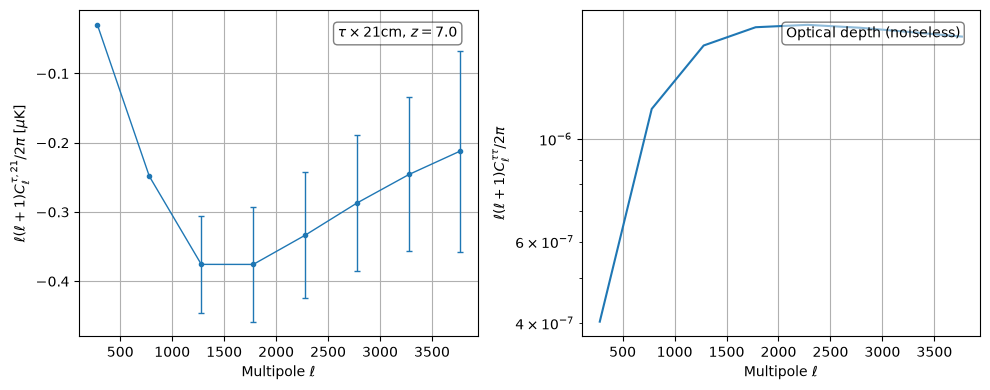

In [8]:
fig, axes = mcmc.plot_cross_obs(cfg, datapoints=datapoints_dict)

In [9]:
sampler = mcmc.run_mcmc(datapoints_dict, cfg)

  0%|          | 0/10 [00:00<?, ?it/s]/data/glx-calcul3/data1/agorce/cross-correlations/preion/.venv/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10/10 [00:21<00:00,  2.16s/it]
/data/glx-calcul3/data1/agorce/cross-correlations/preion/.venv/lib/python3.11/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]
/data/glx-calcul3/data1/agorce/cross-correlations/preion/src/preion/forecast/mcmc.py:463: RuntimeWarning: All-NaN slice encountered
  endtau = np.nanmax(taus)
/data/glx-calcul3/data1/agorce/cross-correlations/preion/src/preion/forecast/mcmc.py:466: RuntimeWarning: All-NaN slice encountered
  burnin = int(max(0.1*samples.shape[0], 2.*np.nanmax(taus)))


## 4. Read back and diagnose the chain

This mirrors what `preion-read-mcmc configs/config_tutorial_mcmc_cross.yaml` does on the
command line: load the chain, compute convergence diagnostics, flatten the
post-burn-in samples, and plot a corner/trace/posterior-predictive figure.

In [10]:
sampler = read_mcmc.load_chain(cfg)
diagnostics = read_mcmc.convergence_diagnostics(sampler)
print(f"Auto-correlation time: {diagnostics['endtau']:.2f}. Converged: {diagnostics['converged']}.")
print(f"burnin = {diagnostics['burnin']} steps")

Auto-correlation time: nan. Converged: False.
burnin = 1 steps


/data/glx-calcul3/data1/agorce/cross-correlations/preion/src/preion/forecast/read_mcmc.py:69: RuntimeWarning: All-NaN slice encountered
  endtau = np.nanmax(taus)


In [11]:
flatsamples, logps = read_mcmc.get_flat_samples(sampler, diagnostics['burnin'])
truths = read_mcmc._theta_true(cfg)
labels = read_mcmc._theta_labels(cfg)
summary = read_mcmc.summarize(flatsamples, truths, read_mcmc.PARAM_NAMES)

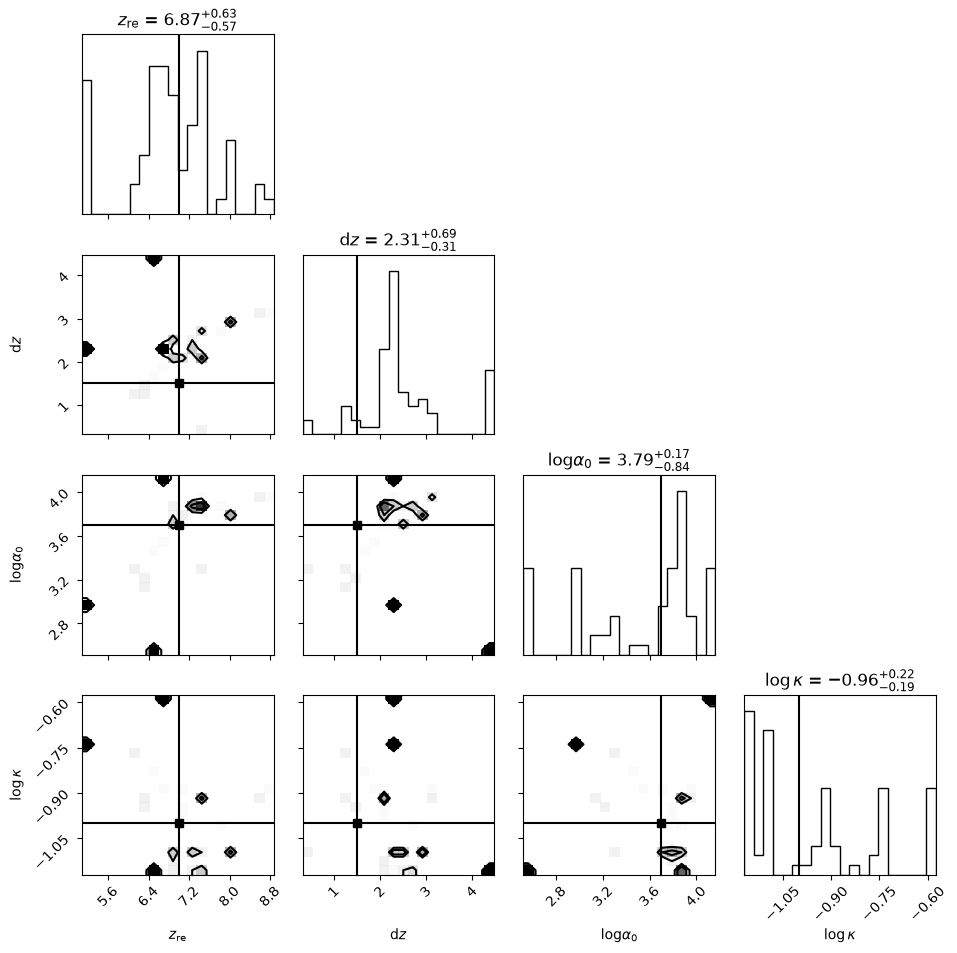

In [12]:
fig_corner = read_mcmc.plot_corner(flatsamples, truths, labels)

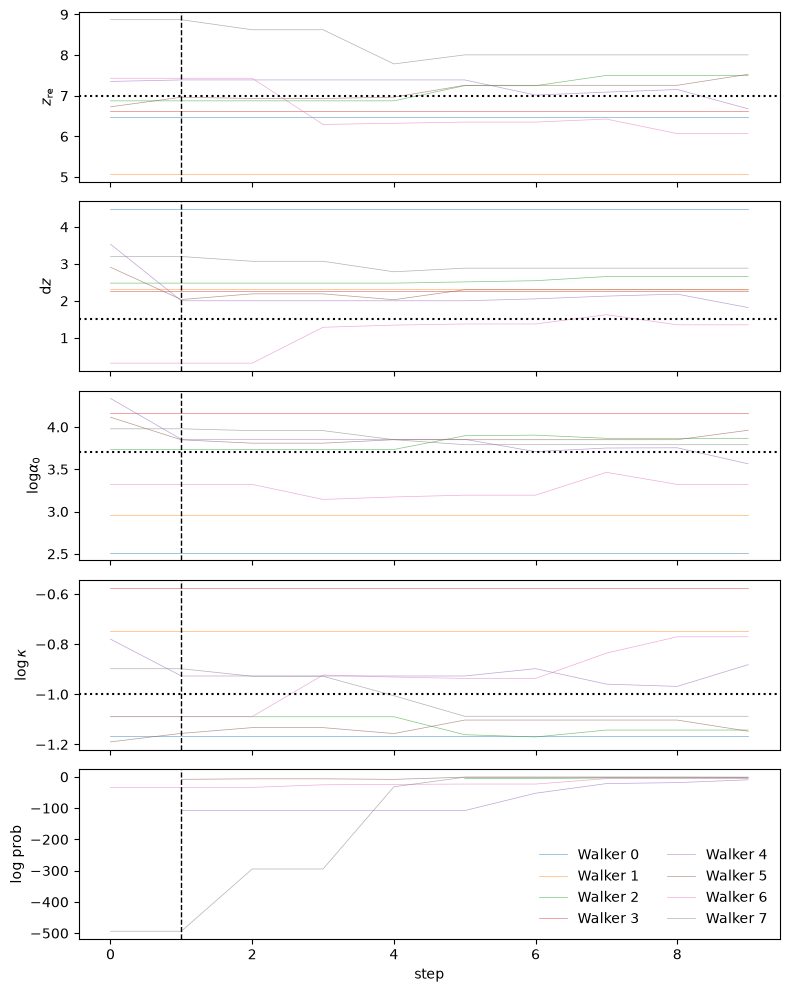

In [13]:
fig_trace = read_mcmc.plot_trace(sampler, truths, labels, diagnostics['burnin'])

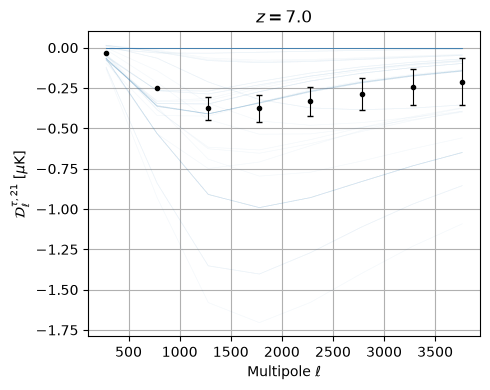

In [14]:
fig_pp = read_mcmc.plot_cross_models(sampler, datapoints_dict, diagnostics['burnin'])

## 5. Clean up the scratch run directory

In [15]:
shutil.rmtree(run_dir, ignore_errors=True)